# 연속데이터예측_아이오와에임스지역_집값예측_train

In [1]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("./data/house_train.csv")
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

결측값 제거

In [6]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageQual        5.547945
GarageFinish      5.547945
GarageYrBlt       5.547945
GarageType        5.547945
GarageCond        5.547945
BsmtExposure      2.602740
BsmtFinType2      2.602740
BsmtFinType1      2.534247
BsmtQual          2.534247
BsmtCond          2.534247
MasVnrArea        0.547945
Electrical        0.068493
1stFlrSF          0.000000
2ndFlrSF          0.000000
LowQualFinSF      0.000000
GrLivArea         0.000000
BsmtFullBath      0.000000
BsmtHalfBath      0.000000
FullBath          0.000000
HalfBath          0.000000
BedroomAbvGr      0.000000
KitchenAbvGr      0.000000
KitchenQual       0.000000
TotRmsAbvGrd      0.000000
Functional        0.000000
Fireplaces        0.000000
CentralAir        0.000000
GarageArea        0.000000
SalePrice         0.000000
Utilities         0.000000
L

In [7]:
data = data.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'], axis=1)

In [8]:
missing_cols = (data.isna().sum() / len(data) * 100).sort_values(ascending=False).index

In [9]:
missing_cols = (data.isna().sum() / len(data) * 100).sort_values(ascending=False).index

In [10]:
missing_cols = ['LotFrontage', 'GarageYrBlt', 'GarageCond', 'GarageType',
       'GarageFinish', 'GarageQual', 'BsmtFinType2', 'BsmtExposure',
       'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'MasVnrArea', 'Electrical']

In [11]:
data['GarageQual'].dtype

dtype('O')

In [12]:
for col in missing_cols:
#     print(col, data[col].dtype)
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

In [13]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)

SalePrice        0.0
Id               0.0
MSSubClass       0.0
GarageArea       0.0
GarageQual       0.0
GarageCond       0.0
PavedDrive       0.0
WoodDeckSF       0.0
OpenPorchSF      0.0
EnclosedPorch    0.0
3SsnPorch        0.0
Neighborhood     0.0
Condition1       0.0
Condition2       0.0
BldgType         0.0
HouseStyle       0.0
OverallQual      0.0
OverallCond      0.0
YearBuilt        0.0
YearRemodAdd     0.0
RoofStyle        0.0
RoofMatl         0.0
Exterior1st      0.0
Exterior2nd      0.0
MasVnrArea       0.0
ExterQual        0.0
ExterCond        0.0
Foundation       0.0
BsmtQual         0.0
BsmtCond         0.0
BsmtExposure     0.0
BsmtFinType1     0.0
BsmtFinSF1       0.0
BsmtFinType2     0.0
BsmtFinSF2       0.0
BsmtUnfSF        0.0
TotalBsmtSF      0.0
Heating          0.0
HeatingQC        0.0
CentralAir       0.0
Electrical       0.0
1stFlrSF         0.0
2ndFlrSF         0.0
LowQualFinSF     0.0
GrLivArea        0.0
BsmtFullBath     0.0
BsmtHalfBath     0.0
FullBath     

이상값 탐지

In [15]:
# !pip install seaborn

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

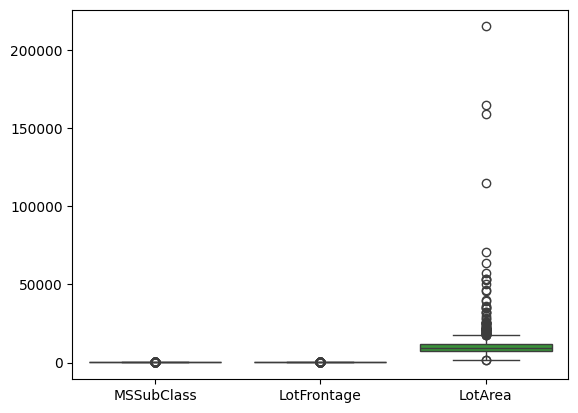

In [18]:
sns.boxplot(data.iloc[:, 1:5])

In [19]:
len(data.columns)

75

<Axes: >

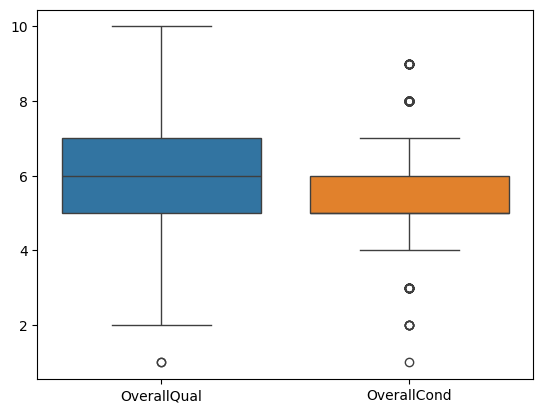

In [20]:
sns.boxplot(data.iloc[:, 16:18])

<Axes: >

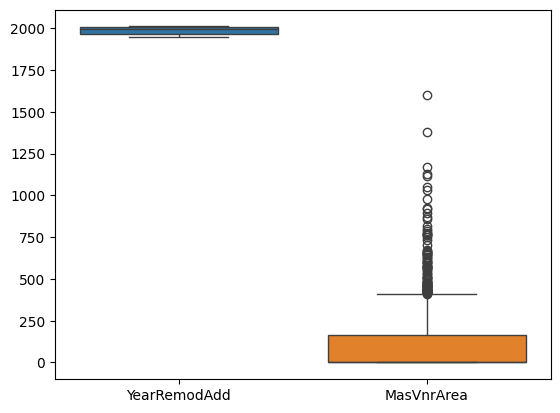

In [21]:
sns.boxplot(data.iloc[:, 19:25])

In [22]:
data2 = data.copy()
data3 = data.copy()

In [23]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'Enclo

In [24]:
X = data.drop(["SalePrice", 'Id'], axis=1)
y = data['SalePrice']

In [25]:
X.head(2)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal


In [26]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [27]:
X = pd.get_dummies(X)
X.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,False,False,False,True,False,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


In [28]:
X = X.astype('float32')

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
rs = RobustScaler()
rs_X_train = rs.fit_transform(X_train)
rs_X_valid = rs.transform(X_valid)


In [32]:
import joblib
joblib.dump(rs, "./model/iowa_rs.joblib")

['./model/iowa_rs.joblib']

# 출력층 Dense(1) 
# model.compile(loss='mean_squared_error', metrics='mse')

In [34]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import RootMeanSquaredError

In [35]:
inputs = Input(shape=(rs_X_train.shape[1], ))
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1)(x)
base_model = Model(inputs=inputs, outputs=outputs)
base_model.summary()

E0000 00:00:1747960374.147744     798 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1747960374.148750     798 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 266)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
base_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path = "./model/iowa_base_model_best.keras"
check_point = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
base_model_history = base_model.fit(rs_X_train, y_train, epochs=1000, batch_size=32,
                                   validation_data=(rs_X_valid, y_valid),
                                   callbacks=[early_stop, check_point],
                                   verbose=1)

Epoch 1/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 40153149440.0000 - root_mean_squared_error: 200356.3438
Epoch 1: val_loss improved from inf to 39370866688.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 39854190592.0000 - root_mean_squared_error: 199610.8750 - val_loss: 39370866688.0000 - val_root_mean_squared_error: 198420.9375
Epoch 2/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 39848800256.0000 - root_mean_squared_error: 199602.6406
Epoch 2: val_loss improved from 39370866688.00000 to 39355944960.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 39763181568.0000 - root_mean_squared_error: 199388.6250 - val_loss: 39355944960.0000 - val_root_mean_squared_error: 198383.3281
Epoch 3/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 40231268352.0000 - root_mean_squared_error: 200534.6875
Epoch 3: val_loss improved from 39355944960.00000 to 39322275840.000

Epoch 18/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 31399110656.0000 - root_mean_squared_error: 177138.6719
Epoch 18: val_loss improved from 35148701696.00000 to 34676547584.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 31657435136.0000 - root_mean_squared_error: 177875.6719 - val_loss: 34676547584.0000 - val_root_mean_squared_error: 186216.4062
Epoch 19/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33204156416.0000 - root_mean_squared_error: 182172.0938
Epoch 19: val_loss improved from 34676547584.00000 to 34189170688.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 32930734080.0000 - root_mean_squared_error: 181421.8281 - val_loss: 34189170688.0000 - val_root_mean_squared_error: 184903.1406
Epoch 20/1000
20/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32258195456.0000 - root_mean_squared_error: 179487.8281
Epoch 20: val_loss improved from 34189170688.0000

Epoch 35/1000
21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25671325696.0000 - root_mean_squared_error: 160199.7500
Epoch 35: val_loss improved from 27327012864.00000 to 26934360064.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25641893888.0000 - root_mean_squared_error: 160114.7500 - val_loss: 26934360064.0000 - val_root_mean_squared_error: 164116.9062
Epoch 36/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25600333824.0000 - root_mean_squared_error: 159812.0781
Epoch 36: val_loss improved from 26934360064.00000 to 26395424768.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 25609684992.0000 - root_mean_squared_error: 159846.9375 - val_loss: 26395424768.0000 - val_root_mean_squared_error: 162466.6875
Epoch 37/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24084193280.0000 - root_mean_squared_error: 155142.6250
Epoch 37: val_loss improved from 26395424768.0000

Epoch 52/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19373443072.0000 - root_mean_squared_error: 139067.0156
Epoch 52: val_loss improved from 19895754752.00000 to 19417999360.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19428192256.0000 - root_mean_squared_error: 139288.7188 - val_loss: 19417999360.0000 - val_root_mean_squared_error: 139348.4844
Epoch 53/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18741078016.0000 - root_mean_squared_error: 136863.5469
Epoch 53: val_loss improved from 19417999360.00000 to 19015043072.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 18877435904.0000 - root_mean_squared_error: 137366.1875 - val_loss: 19015043072.0000 - val_root_mean_squared_error: 137895.0469
Epoch 54/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18909038592.0000 - root_mean_squared_error: 137483.1562
Epoch 54: val_loss improved from 19015043072.0000

Epoch 69/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11810067456.0000 - root_mean_squared_error: 108632.2266
Epoch 69: val_loss improved from 12060088320.00000 to 11536424960.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 11832644608.0000 - root_mean_squared_error: 108741.9453 - val_loss: 11536424960.0000 - val_root_mean_squared_error: 107407.7500
Epoch 70/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11687947264.0000 - root_mean_squared_error: 108052.6094
Epoch 70: val_loss improved from 11536424960.00000 to 11084903424.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 11682857984.0000 - root_mean_squared_error: 108032.5547 - val_loss: 11084903424.0000 - val_root_mean_squared_error: 105284.8672
Epoch 71/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11400384512.0000 - root_mean_squared_error: 106739.1719
Epoch 71: val_loss improved from 11084903424.0000

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5401686528.0000 - root_mean_squared_error: 73461.3750
Epoch 86: val_loss improved from 5235845120.00000 to 4940641280.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5411516928.0000 - root_mean_squared_error: 73528.3359 - val_loss: 4940641280.0000 - val_root_mean_squared_error: 70289.6953
Epoch 87/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7223779328.0000 - root_mean_squared_error: 84445.9453
Epoch 87: val_loss improved from 4940641280.00000 to 4722320384.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7079996416.0000 - root_mean_squared_error: 83628.4766 - val_loss: 4722320384.0000 - val_root_mean_squared_error: 68719.1406
Epoch 88/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4951316480.0000 - root_mean_squared_error: 70218.7969
Epoch 88: val_loss improved from 4722320384.00000 to 4500574720.00000, saving mod

24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4623987712.0000 - root_mean_squared_error: 67794.1641
Epoch 103: val_loss improved from 2626003968.00000 to 2540083968.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4434126848.0000 - root_mean_squared_error: 66396.8984 - val_loss: 2540083968.0000 - val_root_mean_squared_error: 50399.2461
Epoch 104/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3909754624.0000 - root_mean_squared_error: 62364.8711
Epoch 104: val_loss improved from 2540083968.00000 to 2476072960.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3884709376.0000 - root_mean_squared_error: 62192.1406 - val_loss: 2476072960.0000 - val_root_mean_squared_error: 49760.1562
Epoch 105/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3698999552.0000 - root_mean_squared_error: 60746.3281
Epoch 105: val_loss improved from 2476072960.00000 to 2429254400.00000, savin

Epoch 121/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3314997504.0000 - root_mean_squared_error: 57488.7461
Epoch 121: val_loss improved from 2021164416.00000 to 2020573312.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3404729344.0000 - root_mean_squared_error: 58268.2148 - val_loss: 2020573312.0000 - val_root_mean_squared_error: 44950.7891
Epoch 122/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3859431680.0000 - root_mean_squared_error: 62075.1055
Epoch 122: val_loss improved from 2020573312.00000 to 2018024704.00000, saving model to ./model/iowa_base_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3796975616.0000 - root_mean_squared_error: 61569.3047 - val_loss: 2018024704.0000 - val_root_mean_squared_error: 44922.4297
Epoch 123/1000
13/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3965542912.0000 - root_mean_squared_error: 62528.0820 
Epoch 123: val_loss did not improve from 2018024704.00000
32/

Epoch 140/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3861624576.0000 - root_mean_squared_error: 62055.4062
Epoch 140: val_loss did not improve from 1889135488.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3824073216.0000 - root_mean_squared_error: 61757.4414 - val_loss: 1944208000.0000 - val_root_mean_squared_error: 44093.1758
Epoch 141/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3246547200.0000 - root_mean_squared_error: 56951.0234
Epoch 141: val_loss did not improve from 1889135488.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3290638592.0000 - root_mean_squared_error: 57339.1953 - val_loss: 1902116992.0000 - val_root_mean_squared_error: 43613.2656
Epoch 142/1000
23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3441827328.0000 - root_mean_squared_error: 58624.9688
Epoch 142: val_loss did not improve from 1889135488.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3359701504.0000 - root_mean_squared_error: 57922.6875 - val_loss: 1906587264.0000 - val_r

In [37]:
pred = base_model.predict(rs_X_valid)
pred = pd.DataFrame(pred, columns=['pred'])
pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


,pred
0,123026.750000
1,272720.937500
2,86939.562500
3,131245.843750
4,268453.250000
...,...
433,83162.578125
434,117599.195312
435,165524.406250
436,141874.468750


In [38]:
y_valid = pd.DataFrame(y_valid)
y_valid_df = y_valid.reset_index(drop=True)
final_result = y_valid_df.join(pred)
final_result

,SalePrice,pred
0,154500,123026.750000
1,325000,272720.937500
2,115000,86939.562500
3,159000,131245.843750
4,315500,268453.250000
...,...,...
433,139000,83162.578125
434,126175,117599.195312
435,205950,165524.406250
436,110000,141874.468750


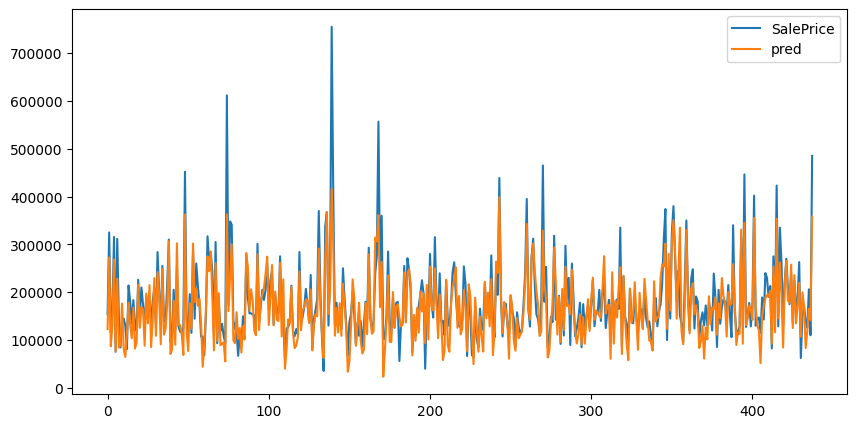

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1964456832.0000 - root_mean_squared_error: 44210.9961
[1889135488.0, 43464.1875]


In [39]:
plt.figure(figsize=(10,5))
plt.plot(final_result['SalePrice'], label='SalePrice')
plt.plot(final_result['pred'], label='pred')
plt.legend()
plt.show()
print(base_model.evaluate(rs_X_valid, y_valid))

# 많은 컬럼 중에 어떤 컬럼을 선택? 266개
* 컬럼의 상관분석을 통해 타겟 변수(종속변수)와 상관도가 높은 컬럼만 선택
* 트리계열 알고리즘을 사용해 분석 후 중요한 변수만 추출해서 재분석

In [40]:
data2

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,0,4,2010,WD,Normal,142125


In [41]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [42]:
data2.drop('Id', axis=1, inplace=True)

In [43]:
data2 = pd.get_dummies(data2)
data2.head(2)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


상관분석

In [44]:
# data2['SalePrice']

In [45]:
corr_rate = data2.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

In [46]:
new_cols1 = corr_rate.head(15).index
new_cols1

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt',
       'GarageArea', 'FullBath', 'TotalBsmtSF', '1stFlrSF', 'ExterQual_Gd',
       'YearRemodAdd', 'GarageYrBlt', 'Foundation_PConc', 'TotRmsAbvGrd',
       'Fireplaces'],
      dtype='object')

In [47]:
new_cols2 = corr_rate.tail(4).index
new_cols2

Index(['KitchenQual_TA', 'BsmtQual_TA', 'GarageFinish_Unf', 'ExterQual_TA'], dtype='object')

In [48]:
final_cols = list(new_cols1) + list(new_cols2)
final_cols

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'YearBuilt',
 'GarageArea',
 'FullBath',
 'TotalBsmtSF',
 '1stFlrSF',
 'ExterQual_Gd',
 'YearRemodAdd',
 'GarageYrBlt',
 'Foundation_PConc',
 'TotRmsAbvGrd',
 'Fireplaces',
 'KitchenQual_TA',
 'BsmtQual_TA',
 'GarageFinish_Unf',
 'ExterQual_TA']

In [49]:
final_cols

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'YearBuilt',
 'GarageArea',
 'FullBath',
 'TotalBsmtSF',
 '1stFlrSF',
 'ExterQual_Gd',
 'YearRemodAdd',
 'GarageYrBlt',
 'Foundation_PConc',
 'TotRmsAbvGrd',
 'Fireplaces',
 'KitchenQual_TA',
 'BsmtQual_TA',
 'GarageFinish_Unf',
 'ExterQual_TA']

In [50]:
data2

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,...,Electrical_Mix,Electrical_SBrkr,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_Fin,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,False,True,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000,False,False,False,True,False,False,True,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [51]:
final_df = data2[final_cols]

In [52]:
final_df

,SalePrice,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,ExterQual_Gd,YearRemodAdd,GarageYrBlt,Foundation_PConc,TotRmsAbvGrd,Fireplaces,KitchenQual_TA,BsmtQual_TA,GarageFinish_Unf,ExterQual_TA
0,208500,7,1710,2,2003,548,2,856,856,True,2003,2003.0,True,8,0,False,False,False,False
1,181500,6,1262,2,1976,460,2,1262,1262,False,1976,1976.0,False,6,1,True,False,False,True
2,223500,7,1786,2,2001,608,2,920,920,True,2002,2001.0,True,6,1,False,False,False,False
3,140000,7,1717,3,1915,642,1,756,961,False,1970,1998.0,False,7,1,False,True,True,True
4,250000,8,2198,3,2000,836,2,1145,1145,True,2000,2000.0,True,9,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000,6,1647,2,1999,460,2,953,953,False,2000,1999.0,True,7,1,True,False,False,True
1456,210000,6,2073,2,1978,500,2,1542,2073,False,1988,1978.0,False,7,2,True,False,True,True
1457,266500,7,2340,1,1941,252,2,1152,1188,False,2006,1941.0,False,9,2,False,True,False,False
1458,142125,5,1078,1,1950,240,1,1078,1078,False,1996,1950.0,False,5,0,False,True,True,True


In [53]:
final_df.corr(method='spearman')

,SalePrice,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,ExterQual_Gd,YearRemodAdd,GarageYrBlt,Foundation_PConc,TotRmsAbvGrd,Fireplaces,KitchenQual_TA,BsmtQual_TA,GarageFinish_Unf,ExterQual_TA
SalePrice,1.000000,0.809829,0.731310,0.690711,0.652682,0.649379,0.635957,0.602725,0.575408,0.574642,0.571159,0.563256,0.562287,0.532586,0.519247,-0.581803,-0.583512,-0.620915,-0.637785
OverallQual,0.809829,1.000000,0.603262,0.608756,0.647392,0.541552,0.576372,0.459915,0.408730,0.603276,0.557723,0.592010,0.586764,0.427806,0.420626,-0.581192,-0.590344,-0.556712,-0.673842
GrLivArea,0.731310,0.603262,1.000000,0.505094,0.288493,0.468211,0.658419,0.371026,0.494421,0.358133,0.282400,0.274625,0.332373,0.827874,0.480804,-0.376159,-0.338674,-0.362334,-0.413922
GarageCars,0.690711,0.608756,0.505094,1.000000,0.601519,0.853317,0.518310,0.455508,0.450580,0.443029,0.456245,0.564786,0.480178,0.386244,0.325520,-0.423255,-0.504415,-0.489950,-0.506121
YearBuilt,0.652682,0.647392,0.288493,0.601519,1.000000,0.528281,0.537420,0.427187,0.293363,0.593575,0.684388,0.845595,0.704001,0.176820,0.174655,-0.512248,-0.700552,-0.632360,-0.644772
GarageArea,0.649379,0.541552,0.468211,0.853317,0.528281,1.000000,0.444459,0.486685,0.489797,0.389859,0.398267,0.540450,0.400205,0.330549,0.264543,-0.393538,-0.413167,-0.449457,-0.453014
FullBath,0.635957,0.576372,0.658419,0.518310,0.537420,0.444459,1.000000,0.328036,0.366891,0.449973,0.431390,0.524892,0.480765,0.558665,0.268548,-0.430333,-0.513693,-0.450629,-0.485598
TotalBsmtSF,0.602725,0.459915,0.371026,0.455508,0.427187,0.486685,0.328036,1.000000,0.829292,0.313044,0.299042,0.319936,0.296406,0.233913,0.325687,-0.307764,-0.317195,-0.385379,-0.383999
1stFlrSF,0.575408,0.408730,0.494421,0.450580,0.293363,0.489797,0.366891,0.829292,1.000000,0.225259,0.240265,0.214327,0.179926,0.361777,0.394883,-0.268281,-0.215559,-0.326525,-0.294636
ExterQual_Gd,0.574642,0.603276,0.358133,0.443029,0.593575,0.389859,0.449973,0.313044,0.225259,1.000000,0.532550,0.569570,0.586748,0.212665,0.181413,-0.617598,-0.541969,-0.483784,-0.906121


<Axes: >

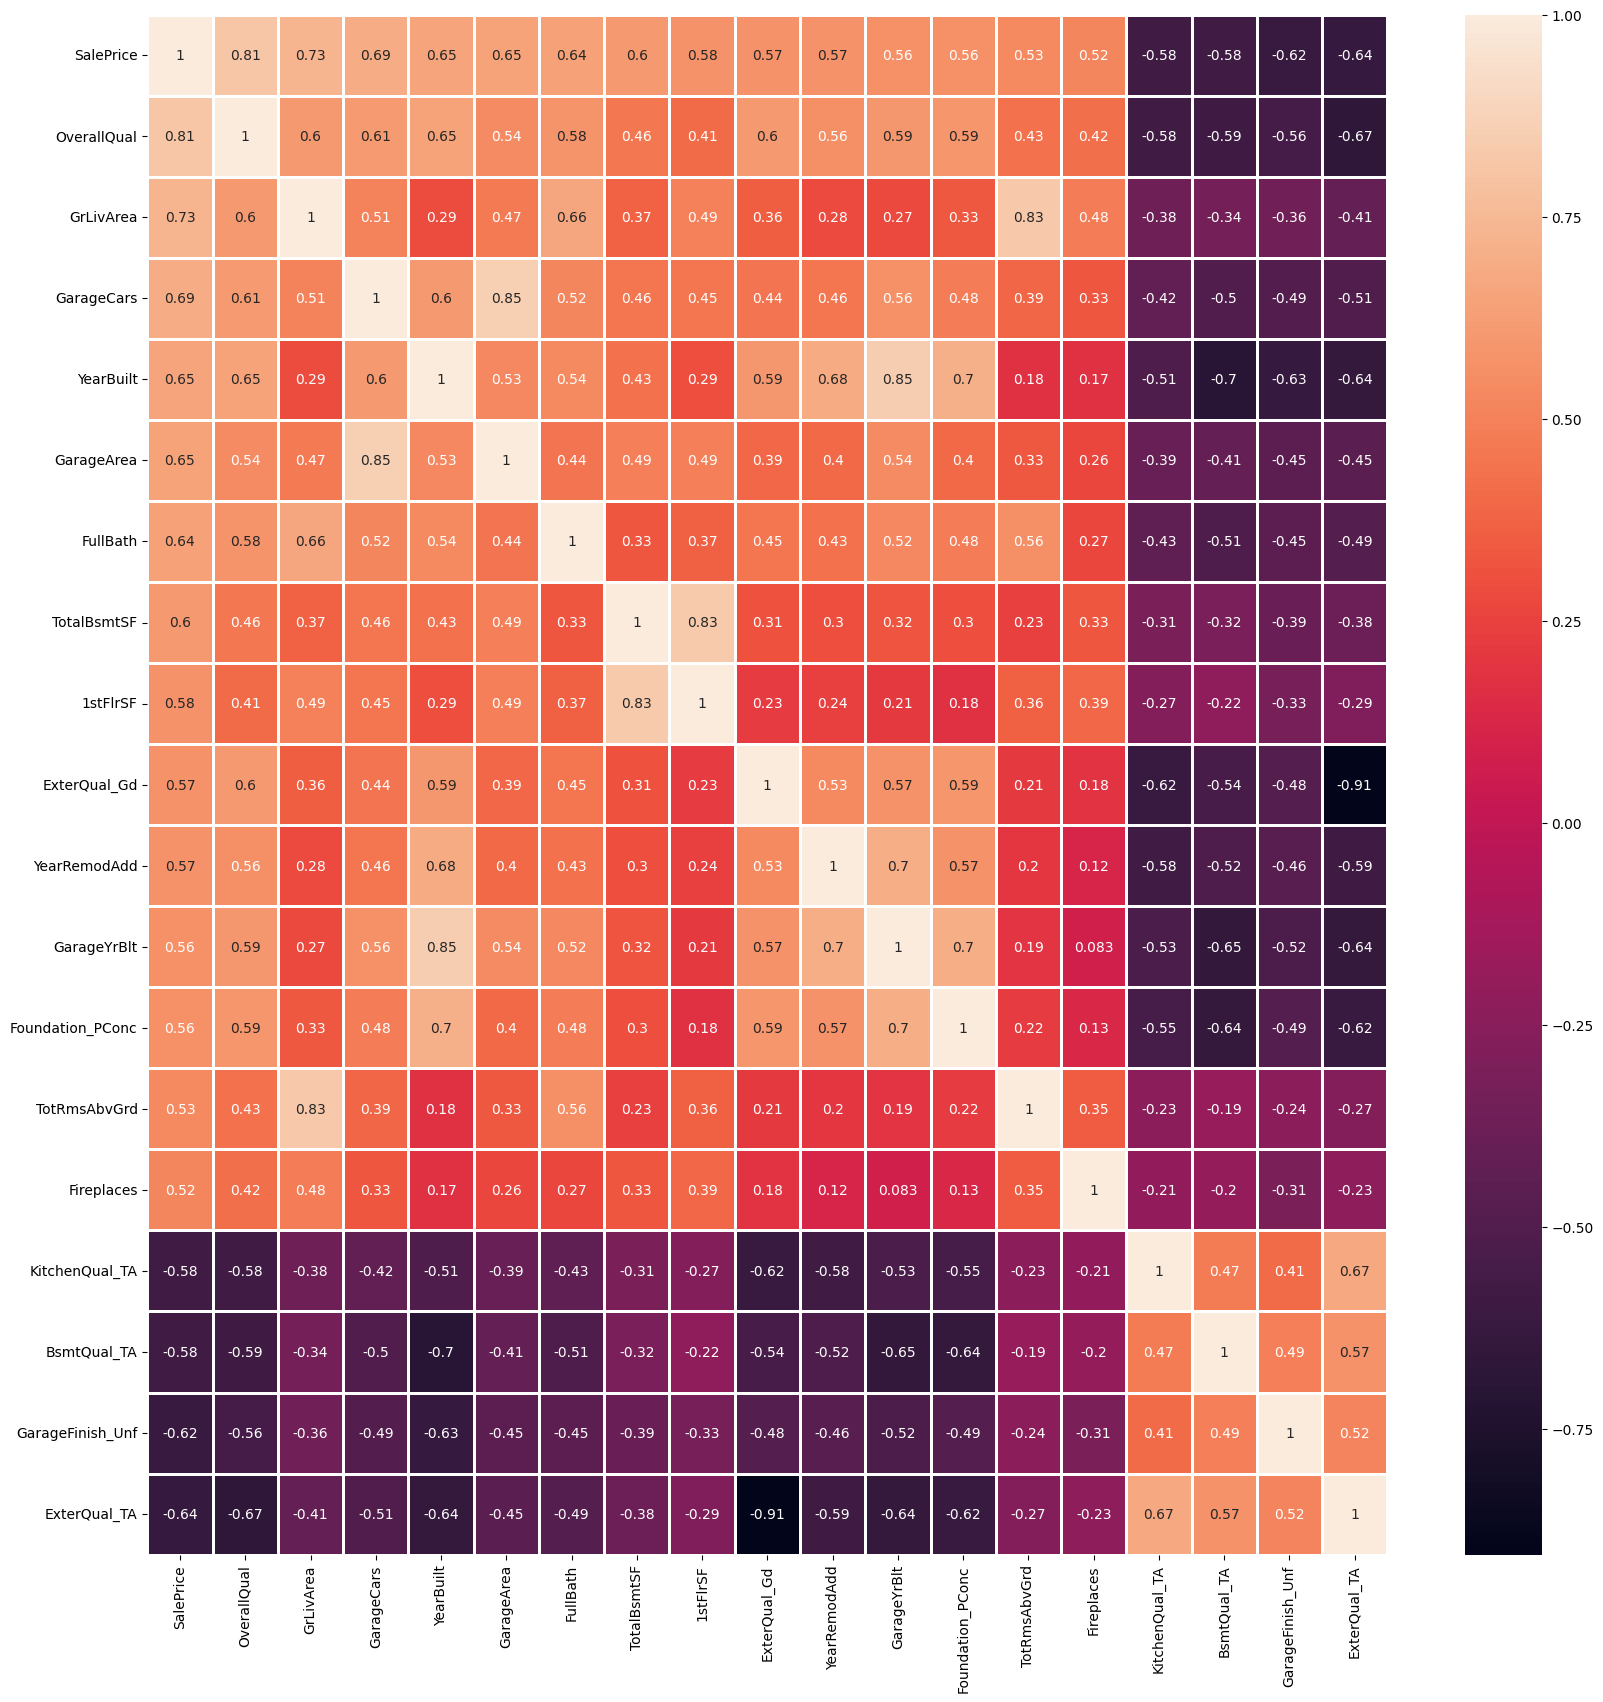

In [54]:
plt.figure(figsize=(20,20))
sns.heatmap(final_df.corr(method='spearman'), annot=True, linewidths=1)

In [56]:
ExterQual_TA - ExterQual_Gd -0.91
BsmtQual_TA - YearBuilt -0.7
BsmtQual_TA - YearBuilt 0.7
TotRmsAbvGrd - GrLivArea 0.83

SyntaxError: invalid syntax (1730232521.py, line 3)

In [57]:
final_df = final_df.drop(['BsmtQual_TA', 'TotRmsAbvGrd','ExterQual_Gd'], axis=1)

In [58]:
X2 = final_df.drop('SalePrice', axis=1)
y2 = final_df['SalePrice']

In [59]:
X2

,OverallQual,GrLivArea,GarageCars,YearBuilt,GarageArea,FullBath,TotalBsmtSF,1stFlrSF,YearRemodAdd,GarageYrBlt,Foundation_PConc,Fireplaces,KitchenQual_TA,GarageFinish_Unf,ExterQual_TA
0,7,1710,2,2003,548,2,856,856,2003,2003.0,True,0,False,False,False
1,6,1262,2,1976,460,2,1262,1262,1976,1976.0,False,1,True,False,True
2,7,1786,2,2001,608,2,920,920,2002,2001.0,True,1,False,False,False
3,7,1717,3,1915,642,1,756,961,1970,1998.0,False,1,False,True,True
4,8,2198,3,2000,836,2,1145,1145,2000,2000.0,True,1,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,1999,460,2,953,953,2000,1999.0,True,1,True,False,True
1456,6,2073,2,1978,500,2,1542,2073,1988,1978.0,False,2,True,True,True
1457,7,2340,1,1941,252,2,1152,1188,2006,1941.0,False,2,False,False,False
1458,5,1078,1,1950,240,1,1078,1078,1996,1950.0,False,0,False,True,True


In [60]:
X2_train, X2_valid, y2_train, y2_valid = train_test_split(X2, y2, test_size=0.3, random_state=42)

In [61]:
rs2 = RobustScaler()
rs2_X2_tarin = rs2.fit_transform(X2_train)
rs2_X2_valid = rs2.transform(X2_valid)

In [62]:
rs2_X2_tarin = rs2_X2_tarin.astype('float32')
rs2_X2_valid = rs2_X2_valid.astype('float32')

In [63]:
inputs = Input(shape=(rs2_X2_tarin.shape[1], ))
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1)(x)
corr_select_model = Model(inputs=inputs, outputs=outputs)
corr_select_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
corr_select_model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_path = "./model/iowa_corr_select_model_best.keras"
check_point = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)
corr_select_model_history = corr_select_model.fit(rs2_X2_tarin, y2_train, epochs=1000, batch_size=32,
                                   validation_data=(rs2_X2_valid, y2_valid),
                                   callbacks=[early_stop, check_point],
                                   verbose=1)

Epoch 1/1000
27/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 41363668992.0000 - root_mean_squared_error: 203327.4219
Epoch 1: val_loss improved from inf to 39380000768.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 40907804672.0000 - root_mean_squared_error: 202198.8594 - val_loss: 39380000768.0000 - val_root_mean_squared_error: 198443.9531
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38337675264.0000 - root_mean_squared_error: 195750.2188
Epoch 2: val_loss improved from 39380000768.00000 to 39378911232.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 38354460672.0000 - root_mean_squared_error: 195794.4375 - val_loss: 39378911232.0000 - val_root_mean_squared_error: 198441.2031
Epoch 3/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38962135040.0000 - root_mean_squared_error: 197376.0000
Epoch 3: val_loss improved from 39378911232.00000 to 3

Epoch 18/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 39350231040.0000 - root_mean_squared_error: 198332.7969
Epoch 18: val_loss improved from 38639636480.00000 to 38496866304.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 39312019456.0000 - root_mean_squared_error: 198236.7969 - val_loss: 38496866304.0000 - val_root_mean_squared_error: 196206.1875
Epoch 19/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 37840248832.0000 - root_mean_squared_error: 194398.1875
Epoch 19: val_loss improved from 38496866304.00000 to 38343663616.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 37872308224.0000 - root_mean_squared_error: 194499.7656 - val_loss: 38343663616.0000 - val_root_mean_squared_error: 195815.3750
Epoch 20/1000
26/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38000242688.0000 - root_mean_squared_error: 194897.6250
Epoch 20: val_loss improved from 38

Epoch 35/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36369506304.0000 - root_mean_squared_error: 190592.4062
Epoch 35: val_loss improved from 33941712896.00000 to 33503252480.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 35607629824.0000 - root_mean_squared_error: 188585.8750 - val_loss: 33503252480.0000 - val_root_mean_squared_error: 183038.9375
Epoch 36/1000
21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 34216773632.0000 - root_mean_squared_error: 184837.0625
Epoch 36: val_loss improved from 33503252480.00000 to 33057701888.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 33759653888.0000 - root_mean_squared_error: 183640.5938 - val_loss: 33057701888.0000 - val_root_mean_squared_error: 181817.7656
Epoch 37/1000
12/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31759962112.0000 - root_mean_squared_error: 178098.5000 
Epoch 37: val_loss improved from 3

Epoch 52/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23741657088.0000 - root_mean_squared_error: 154031.9062
Epoch 52: val_loss improved from 24892944384.00000 to 24289742848.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 23752583168.0000 - root_mean_squared_error: 154068.7812 - val_loss: 24289742848.0000 - val_root_mean_squared_error: 155851.6719
Epoch 53/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22958579712.0000 - root_mean_squared_error: 151493.8281
Epoch 53: val_loss improved from 24289742848.00000 to 23685206016.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 22986360832.0000 - root_mean_squared_error: 151585.4219 - val_loss: 23685206016.0000 - val_root_mean_squared_error: 153899.9844
Epoch 54/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24873232384.0000 - root_mean_squared_error: 157607.5938
Epoch 54: val_loss improved from 23

Epoch 69/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14553423872.0000 - root_mean_squared_error: 120594.1641
Epoch 69: val_loss improved from 15016032256.00000 to 14500531200.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 14636179456.0000 - root_mean_squared_error: 120940.4844 - val_loss: 14500531200.0000 - val_root_mean_squared_error: 120418.1484
Epoch 70/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15168588800.0000 - root_mean_squared_error: 123136.4844
Epoch 70: val_loss improved from 14500531200.00000 to 13990280192.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 15089917952.0000 - root_mean_squared_error: 122822.1250 - val_loss: 13990280192.0000 - val_root_mean_squared_error: 118280.5156
Epoch 71/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14274810880.0000 - root_mean_squared_error: 119461.9531
Epoch 71: val_loss improved from 13

...

Epoch 350/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3729632768.0000 - root_mean_squared_error: 60962.2148
Epoch 350: val_loss improved from 2100724352.00000 to 2090399744.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3734911232.0000 - root_mean_squared_error: 61011.7539 - val_loss: 2090399744.0000 - val_root_mean_squared_error: 45720.8906
Epoch 351/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3343099392.0000 - root_mean_squared_error: 57601.1758
Epoch 351: val_loss improved from 2090399744.00000 to 2087932672.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3434661632.0000 - root_mean_squared_error: 58424.5742 - val_loss: 2087932672.0000 - val_root_mean_squared_error: 45693.9023
Epoch 352/1000
23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3221412096.0000 - root_mean_squared_error: 56636.7617
Epoch 352: val_loss improved from 2087932672.000

Epoch 368/1000
24/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3462973184.0000 - root_mean_squared_error: 58804.6523
Epoch 368: val_loss improved from 2039905664.00000 to 2035534208.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3581278720.0000 - root_mean_squared_error: 59790.7930 - val_loss: 2035534208.0000 - val_root_mean_squared_error: 45116.8945
Epoch 369/1000
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3461650176.0000 - root_mean_squared_error: 58477.4648
Epoch 369: val_loss improved from 2035534208.00000 to 2019074560.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3461971968.0000 - root_mean_squared_error: 58501.9180 - val_loss: 2019074560.0000 - val_root_mean_squared_error: 44934.1133
Epoch 370/1000
21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3561162496.0000 - root_mean_squared_error: 59573.6523
Epoch 370: val_loss improved from 2019074560.000

Epoch 386/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3320008704.0000 - root_mean_squared_error: 57554.6328
Epoch 386: val_loss did not improve from 1974829056.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ -1s -36305us/step - loss: 3363794176.0000 - root_mean_squared_error: 57936.2852 - val_loss: 1981315712.0000 - val_root_mean_squared_error: 44511.9727
Epoch 387/1000
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3472834048.0000 - root_mean_squared_error: 58903.7734
Epoch 387: val_loss did not improve from 1974829056.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3512479744.0000 - root_mean_squared_error: 59235.8398 - val_loss: 1985041536.0000 - val_root_mean_squared_error: 44553.8047
Epoch 388/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3507195904.0000 - root_mean_squared_error: 59193.5703
Epoch 388: val_loss improved from 1974829056.00000 to 1973407616.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 350257382

23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3374440448.0000 - root_mean_squared_error: 57998.0938
Epoch 404: val_loss improved from 1915302016.00000 to 1905382784.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3438939136.0000 - root_mean_squared_error: 58570.0625 - val_loss: 1905382784.0000 - val_root_mean_squared_error: 43650.6914
Epoch 405/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4079633408.0000 - root_mean_squared_error: 63629.9570
Epoch 405: val_loss improved from 1905382784.00000 to 1905036032.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4056973568.0000 - root_mean_squared_error: 63471.7734 - val_loss: 1905036032.0000 - val_root_mean_squared_error: 43646.7188
Epoch 406/1000
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3613272576.0000 - root_mean_squared_error: 59970.7461
Epoch 406: val_loss did not improve from 1905036032.00000
32/32

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3609889280.0000 - root_mean_squared_error: 60027.5820
Epoch 422: val_loss did not improve from 1871972224.00000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3589267456.0000 - root_mean_squared_error: 59860.4727 - val_loss: 1878638208.0000 - val_root_mean_squared_error: 43343.2617
Epoch 423/1000
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3531353088.0000 - root_mean_squared_error: 59377.6289
Epoch 423: val_loss improved from 1871972224.00000 to 1866771456.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3518832384.0000 - root_mean_squared_error: 59274.7148 - val_loss: 1866771456.0000 - val_root_mean_squared_error: 43206.1523
Epoch 424/1000
30/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3433951232.0000 - root_mean_squared_error: 58424.8281
Epoch 424: val_loss improved from 1866771456.00000 to 1862252288.00000, saving model to ./model/iowa_corr_select_model_best.keras
32/32

In [65]:
pred = corr_select_model.predict(rs2_X2_valid)
pred = pd.DataFrame(pred, columns=['pred'])
pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


,pred
0,82613.515625
1,312044.156250
2,112309.218750
3,137309.796875
4,288754.687500
...,...
433,77114.859375
434,75299.281250
435,201118.156250
436,117249.765625


In [66]:
y2_valid = pd.DataFrame(y2_valid)
y2_valid_df = y2_valid.reset_index(drop=True)
final_result = y2_valid_df.join(pred)
final_result

,SalePrice,pred
0,154500,82613.515625
1,325000,312044.156250
2,115000,112309.218750
3,159000,137309.796875
4,315500,288754.687500
...,...,...
433,139000,77114.859375
434,126175,75299.281250
435,205950,201118.156250
436,110000,117249.765625


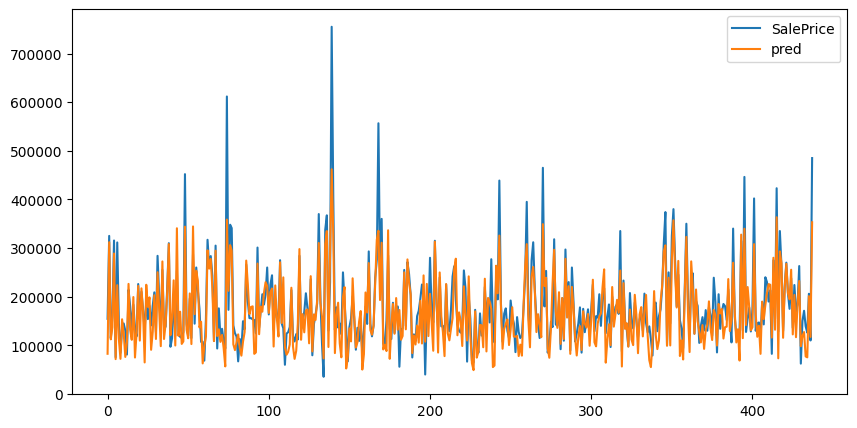

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1903794816.0000 - root_mean_squared_error: 43492.5977 
[1853059584.0, 43047.1796875]


In [67]:
plt.figure(figsize=(10,5))
plt.plot(final_result['SalePrice'], label='SalePrice')
plt.plot(final_result['pred'], label='pred')
plt.legend()
plt.show()
print(corr_select_model.evaluate(rs2_X2_valid, y2_valid))